In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
from insightface.app import FaceAnalysis
import cv2
app = FaceAnalysis(name='antelopev2', root='../', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))
def get_embedding(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (160,160))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    face = faces[0]
    embedding = face.embedding
    return embedding    
import numpy as np
def cosine_similarity(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return np.dot(a, b)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (160, 160)


In [210]:
import torch
import torch.nn.functional as F
import random
from torchjpeg import dct

def dct_transform(x, chs_remove=None, chs_pad=False):
    assert x.shape[1] == 3
    size = random.choice([8]); stride = size; pad = 0; dilation = 1; ratio = size

    x = x * 0.5 + 0.5

    # up-sample
    x = F.interpolate(x, scale_factor=ratio, mode='bilinear', align_corners=True)

    # convert to the YCbCr color domain, required by DCT
    x = x * 0.5
    x = dct.to_ycbcr(x)
    x = x - 0.5

    # perform block discrete cosine transform (BDCT)
    b, c, h, w = x.shape
    n_block = h // stride
    x = x.view(b * c, 1, h, w)
    x = F.unfold(x, kernel_size=(size, size), dilation=dilation, padding=pad, stride=(stride, stride))
    x = x.transpose(1, 2)
    x = x.view(b, c, -1, size, size)
    x_freq = dct.block_dct(x)
    x_freq = x_freq.view(b, c, n_block, n_block, size * size).permute(0, 1, 4, 2, 3)
    chs_remove = list(range(1))
    channels = list(set([i for i in range(x_freq.shape[2])]) - set(chs_remove)) 
    # channels = random.sample(channels, random.randint(len(channels)//3, len(channels)))
    x_freq = x_freq[:, :, channels, :, :]

    x_freq = x_freq.reshape(b, -1, n_block, n_block)
    x_freq = x_freq.mean(dim=1, keepdim=True).repeat(1,3,1,1) # mean at last

    # noise = torch.randn_like(x_freq) * x_freq.std() * 0.1
    # x_freq = x_freq + noise
    return x_freq

In [211]:

import sys
import torch
sys.path.insert(0, "../../")
from minusface import MinusBackbone

conversion_model = MinusBackbone(mode='stage1')
conversion_model.load_state_dict(torch.load("../../checkpoints/minusface_stage1.pth", map_location='cpu'))
conversion_model = conversion_model.eval().to("cuda")


In [212]:
import numpy as np
from PIL import Image
def convert_batch(conv_raw):
    conv_raw = conv_raw.to("cuda")
    with torch.no_grad():
        out = conversion_model(conv_raw)[5]

    imgs = out.float()
    minv = imgs.amin(dim=(1, 2, 3), keepdim=True)
    maxv = imgs.amax(dim=(1, 2, 3), keepdim=True)
    imgs = (imgs - minv) / (maxv - minv + 1e-6)
    imgs = np.array(imgs.cpu().detach().permute(0, 2, 3, 1)[0]) * 255.0
    imgs = cv2.GaussianBlur(imgs, (0,0), 0.3)
    imgs = imgs[None]
    imgs = torch.tensor(imgs).permute(0, 3, 1, 2) / 255.0
    print(imgs.shape)


    imgs = dct_transform(imgs)
    print(imgs.shape)
    minv = imgs.amin(dim=(1, 2, 3), keepdim=True)
    maxv = imgs.amax(dim=(1, 2, 3), keepdim=True)
    imgs = (imgs - minv) / (maxv - minv + 1e-6)
    Image.fromarray((imgs[0].permute(1,2,0).cpu().numpy() * 255).astype("uint8")).save("debug_minus.png")
    imgs = torch.tensor(np.array(imgs.cpu().detach()))

    return imgs

In [213]:
from torchvision import transforms
tf_conv = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])


In [214]:
# from deepface import DeepFace
# img_s = DeepFace.extract_faces("0001.png", detector_backend = "opencv", enforce_detection=False)[0]["face"] 

In [215]:
import numpy as np
from PIL import Image
from PIL import ImageFilter
img = Image.open("0001.png").convert("RGB")
template = convert_batch(tf_conv(img).unsqueeze(0))
# template = convert_batch(tf_conv(Image.fromarray((img_s * 255).astype(np.uint8)).convert("RGB")).unsqueeze(0))

torch.Size([1, 3, 112, 112])
torch.Size([1, 3, 112, 112])


In [216]:
import kornia

def fix_stripes(img_tensor):
    return kornia.enhance.equalize_clahe(img_tensor, 2.0, (16, 16))


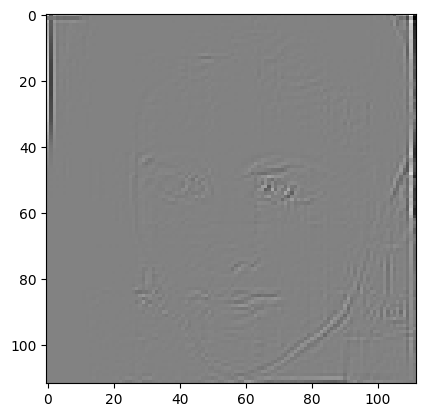

In [227]:
import pylab
t = template.cpu().numpy()[0].transpose(1, 2, 0)
t = t - cv2.GaussianBlur(t, (0,0), 0.3) + 128 
t = (t - t.min()) / (t.max() - t.min() + 1e-6)
pylab.imshow(t, cmap='gray')   

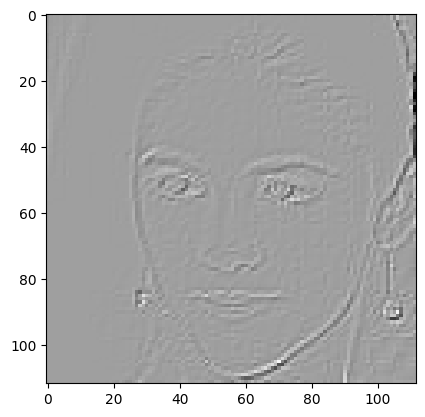

In [218]:
import cv2 

raw = cv2.imread("0001.png").mean(axis=-1)
raw = raw - cv2.GaussianBlur(raw, (0,0), 0.3) + 128
raw = cv2.resize(raw, (112,112))
raw = dct_transform(torch.tensor(raw).unsqueeze(0).unsqueeze(0).float().repeat(1, 3, 1, 1) / 255.0).squeeze().cpu().numpy().transpose(1, 2, 0)
raw = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)
pylab.imshow(raw, cmap='gray')

In [219]:
template.max()

tensor(0.9997)

In [220]:
import torch
from onnx2torch import convert

onnx_model_path = "../../checkpoints/model.onnx"

student = convert(onnx_model_path)

In [221]:
student = torch.nn.Sequential(
    student,
)

In [222]:
student.load_state_dict(torch.load("student.pth.bak", map_location='cpu'))

<All keys matched successfully>

In [223]:
template = (template - template.min()) / (template.max() - template.min())

In [224]:
partial_face = cv2.imread("debug_partial.png")
partial_face = cv2.resize(partial_face, (112,112))
partial_face = torch.tensor(partial_face).permute(2,0,1).unsqueeze(0).float() / 255.0

In [225]:
t = torch.tensor(t).permute(2,0,1).unsqueeze(0).float() / 255.0

In [226]:
student = student.eval() 
raw = cv2.imread("0001.png").mean(axis=-1)
raw = raw - cv2.GaussianBlur(raw, (0,0), 0.3) + 128
raw = cv2.resize(raw, (112,112))
t = dct_transform(torch.tensor(raw).unsqueeze(0).unsqueeze(0).float().repeat(1, 3, 1, 1))
t = (t - t.min()) / (t.max() - t.min())
print(t.mean())
pred_0 = student(t) 


t = template.cpu().numpy()[0].transpose(1, 2, 0)
t = t - cv2.GaussianBlur(t, (0,0), 0.3) + 128
t = (t - t.min()) / (t.max() - t.min() + 1e-6)
t = torch.tensor(t).permute(2,0,1).unsqueeze(0).float()
print(t.mean())
pred = student(t) 
cosine_similarity(get_embedding("0001.png"), pred_0[0].cpu().detach().numpy()), cosine_similarity(pred_0[0].cpu().detach().numpy(), pred[0].cpu().detach().numpy())

tensor(0.6462)
tensor(0.5108)


(0.61895823, 0.36957586)